In [ ]:
with open("/home/enzo/Documents/Zombi/ZOMBI/zombi-rs/rustree/species_tree_test_2.tre", "r") as f:
    newick_str = f.read()
newick_str
from ete3 import Tree

In [ ]:
t = Tree(newick_str, format=1)

In [ ]:
import rustree

species_tree = rustree.parse_species_tree(newick_str)

In [ ]:
species_tree

In [ ]:
import time
start_time = time.time()
species_tree = rustree.simulate_species_tree(
    20,
    1,
    0)
gene_trees = species_tree.simulate_dtl_batch(
    n=10,
    lambda_d=0.0,
    lambda_t=0.5,
    lambda_l=0.01,
    seed=1234,
    transfer_alpha=10,
)
end_time = time.time()
print(f"Simulated 10000 gene trees in {end_time - start_time} seconds.")
gene_trees[0].display()

In [ ]:
gene_trees[0].display()

In [ ]:
gene_trees[0].num_nodes()

In [ ]:
from ete3 import Tree 
list_nb_nodes = []
for tree in gene_trees:
    list_nb_nodes.append((tree.num_nodes()+1)/2)  # number of leaves

In [ ]:
# Do histogram of list_nb_nodes
import matplotlib.pyplot as plt
plt.hist(list_nb_nodes, bins=30)
plt.xlabel("Number of leaves")
plt.ylabel("Frequency")
plt.title("Histogram of number of leaves in simulated gene trees")
plt.show()

In [ ]:
import rustree

# species_tree = rustree.simulate_species_tree(1000, 1.0, 0.0, seed=42)
with open("/home/enzo/Documents/Zombi/ZOMBI/zombi-rs/rustree/species_tree_test.tre", "r") as f:
    newick_str = f.read()
species_tree = rustree.parse_species_tree(newick_str)

# Batch simulation (faster than loop)
gene_trees = species_tree.simulate_dtl_batch(
    n=1000,
    lambda_d=0.05,
    lambda_t=0.02,
    lambda_l=0.01,
    seed=123
)

# For a single gene tree:
gene_tree = gene_trees[0]

# Save XML to file
gene_tree.save_xml("tree.xml")

# Get DataFrame (optionally save to CSV)
df = gene_tree.to_csv("tree.csv")  # saves and returns DataFrame
df = gene_tree.to_csv()             # just returns DataFrame, no save


In [ ]:
import time
start = time.time()
for i in range(1):
    gene_trees = species_tree.simulate_dtl_batch(
        n=1000,
        lambda_d=0.1,
        lambda_t=0.1,
        lambda_l=0.0,
        seed=123
    )
    gene_tree = gene_trees[0]
end = time.time()
print(f"Elapsed time: {end - start} seconds")   

In [ ]:
gene_tree.to_svg(open_browser=True)

In [ ]:
gene_tree.display()

In [ ]:
df

In [ ]:
species_tree.to_newick()

In [1]:
import rustree

# Load species tree
species_tree = rustree.parse_species_tree("test_data_3/output_zombi/T/ExtantTree.nwk")

# Reconcile gene tree with ALERax
results = rustree.reconcile_with_alerax(
    species_tree=species_tree,
    gene_trees="test_data_3/output_zombi/G/Gene_trees/1_prunedtree.nwk",
    seed=42
)

# Access results
result = results["1_prunedtree"]
print(f"Samples: {len(result.gene_trees)}")  # 100 reconciliation samples
print(f"D={result.duplication_rate:.4f}, T={result.transfer_rate:.4f}")

# Use with existing functionality
best_tree = result.gene_trees[0]
best_tree.to_svg("reconciled.svg", open_browser=True)
events = best_tree.count_events()

Samples: 100
D=0.0983, T=0.0663


Running ALERax command: "alerax" "-s" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpMvuk5a/input/species_tree.newick" "-f" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpMvuk5a/input/families.txt" "-p" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpMvuk5a/alerax_output" "--model-parametrization" "PER-FAMILY" "--gene-tree-samples" "100" "--seed" "42"


In [4]:
result

PyAleRaxResult(samples=100, D=0.0983, L=0.0000, T=0.0663, logL=-51.07)

In [2]:
import rustree
gene_trees="test_data_3/output_zombi/G/Gene_trees/1_prunedtree.nwk"
species_tree = rustree.parse_species_tree("species.nwk")
results = rustree.reconcile_with_alerax(species_tree, gene_trees, seed=42)

# Access statistics
result = results["family_1"]
stats = result.statistics

# Mean event counts
print(f"Mean duplications: {stats.mean_event_counts.duplications:.2f}")
print(f"Mean transfers: {stats.mean_event_counts.transfers:.2f}")

# Transfers between species
for source, dests in stats.mean_transfers.items():
    for dest, count in dests.items():
        print(f"{source} → {dest}: {count:.2f}")

# Events per species
for species, events in stats.events_per_species.items():
    print(f"{species}: D={events.duplications:.1f}, T={events.transfers:.1f}")


ValueError: Input validation failed: Gene tree '1_prunedtree' has leaves not in species tree: ["n10", "n12", "n13", "n11", "n8", "n14", "n9", "n5"]

In [1]:
import rustree

species_tree = rustree.parse_species_tree("test_data_3/output_zombi/T/ExtantTree.nwk")
gene_trees = "test_data_3/output_zombi/G/Gene_trees/1_prunedtree.nwk"
results = rustree.reconcile_with_alerax(species_tree, gene_trees, seed=42)

result = results["1_prunedtree"]
stats = result.statistics

# Mean transfers as a DataFrame
print("Mean transfers between species:")
display(stats.transfers_df())

# Events per species as a DataFrame
print("\nMean events per species:")
display(stats.events_df())


Mean transfers between species:


Running ALERax command: "alerax" "-s" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpYrlWXe/input/species_tree.newick" "-f" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpYrlWXe/input/families.txt" "-p" "/var/folders/st/n66ymkgd7pv7ym2ktsgtcwbw0000gn/T/.tmpYrlWXe/alerax_output" "--model-parametrization" "PER-FAMILY" "--gene-tree-samples" "100" "--seed" "42"


,source,destination,mean_count
0,n7,n4,0.99
1,n7,n13,0.01
2,n9,n8,1.00
3,n13,n14,0.01
4,n6,n2,1.00
5,n10,n11,1.00



Mean events per species:


,species,speciations,speciation_losses,duplications,duplication_losses,transfers,transfer_losses,losses,leaves
0,Root,3.00,0.0,2.0,0.0,0.00,0.0,0.0,0.0
1,n1,3.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0
2,n10,0.00,0.0,0.0,0.0,1.00,0.0,0.0,4.0
3,n11,0.00,0.0,0.0,0.0,0.00,0.0,0.0,5.0
4,n12,0.00,0.0,0.0,0.0,0.00,0.0,0.0,4.0
5,n13,0.00,0.0,0.0,0.0,0.01,0.0,0.0,4.0
6,n14,0.00,0.0,1.0,0.0,0.00,0.0,0.0,5.0
7,n2,4.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0
8,n3,3.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0
9,n4,3.99,0.0,0.0,0.0,0.00,0.0,0.0,0.0


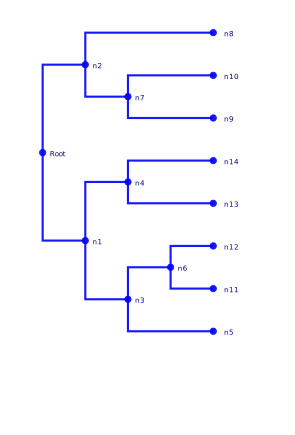

In [5]:
species_tree.display()